### PROJECT OVERVIEW
The Crop Disease Detection project leverages deep learning to automatically diagnose plant health from leaf images, empowering farmers with early intervention tools. Using convolutional neural networks (CNNs)—often via pre-trained architectures like ResNet or custom models—the system analyzes vast image datasets like PlantVillage, which contain tens of thousands of categorized healthy and infected leaves. The pipeline involves image preprocessing, data augmentation, and rigorous model training in environments like Google Colab using TensorFlow and Keras. Ultimately, this precision agriculture solution provides rapid, accurate disease identification, drastically reducing crop loss and enabling accessible, on-the-go diagnostics through mobile applications.

In [2]:
!pip install torch

In [3]:
%pip install torch torchvision torchaudio numpy matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Cell 1: Setup & Hardware Acceleration
import os
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [5]:
# Cell 2: Local Path Configuration
# Root path relative to 'Crop_Disease_Detection.ipynb'
DATASET_DIR = "." 

TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
VAL_DIR = os.path.join(DATASET_DIR, "Val")
TEST_DIR = os.path.join(DATASET_DIR, "Test")

# Verify local directory existence
print(f"Train directory exists: {os.path.exists(TRAIN_DIR)}")
print(f"Val directory exists  : {os.path.exists(VAL_DIR)}")
print(f"Test directory exists : {os.path.exists(TEST_DIR)}")

Train directory exists: True
Val directory exists  : True
Test directory exists : True


In [6]:
# Cell 3: Data Augmentations & DataLoaders
IMG_SIZE = 224
BATCH_SIZE = 32

# Data Transformations & Feature Engineering
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load Image Datasets from Local Directory Folders
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transforms)

# Initialize DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"✅ Loaded {num_classes} classes from local directory:")
for idx, clsname in enumerate(class_names):
    print(f"  [{idx}] {clsname}")

print(f"\nTotal Samples -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

✅ Loaded 29 classes from local directory:
  [0] Apple - Apple Scab
  [1] Apple - Black Rot
  [2] Apple - Cedar Apple Rust
  [3] Apple - Healthy
  [4] Bell Pepper - Bacterial Spot
  [5] Bell Pepper - Healthy
  [6] Cherry - Healthy
  [7] Cherry - Powdery Mildew
  [8] Corn (Maize) - Cercospora Leaf Spot
  [9] Corn (Maize) - Common Rust
  [10] Corn (Maize) - Healthy
  [11] Corn (Maize) - Northern Leaf Blight
  [12] Grape - Black Rot
  [13] Grape - Esca (Black Measles)
  [14] Grape - Healthy
  [15] Grape - Leaf Blight
  [16] Peach - Bacterial Spot
  [17] Peach - Healthy
  [18] Potato - Early Blight
  [19] Potato - Healthy
  [20] Potato - Late Blight
  [21] Strawberry - Healthy
  [22] Strawberry - Leaf Scorch
  [23] Tomato - Bacterial Spot
  [24] Tomato - Early Blight
  [25] Tomato - Healthy
  [26] Tomato - Late Blight
  [27] Tomato - Septoria Leaf Spot
  [28] Tomato - Yellow Leaf Curl Virus

Total Samples -> Train: 53693 | Val: 12067 | Test: 1358


c:\Users\priya\OneDrive\Desktop\VSCODE\Python Practice\venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


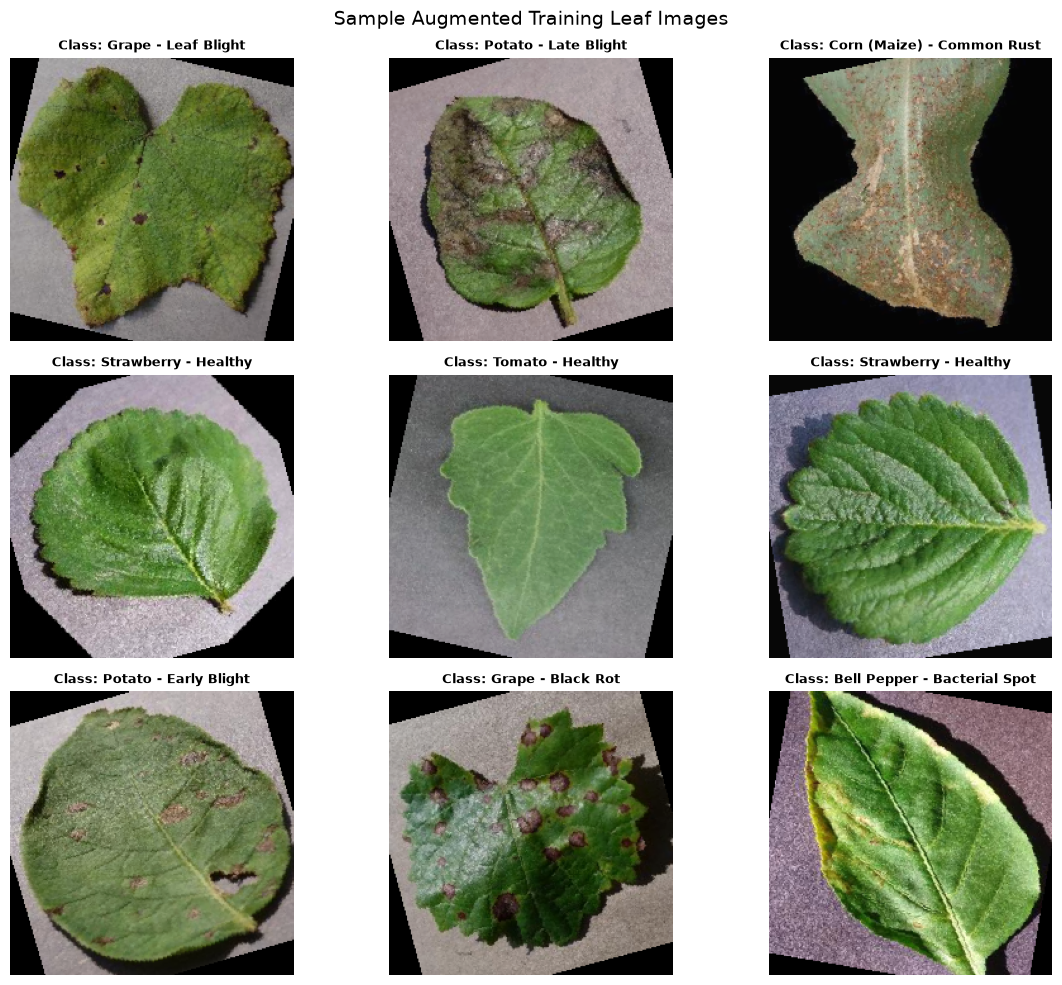

In [7]:
# Cell 4: Visualizing Sample Training Images
def denormalize(tensor):
    # Reverses ImageNet normalization for plotting
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 10))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"Class: {class_names[labels[i]]}", fontsize=9, fontweight='bold')
    plt.axis('off')

plt.suptitle("Sample Augmented Training Leaf Images", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Cell 5: PyTorch Model Definition
class CropDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super(CropDiseaseCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CropDiseaseCNN(num_classes=num_classes).to(device)
print(model)

CropDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchN

In [9]:
# Cell 6: Loss, Optimizer & Scheduler Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=2
)

print("✅ Loss criterion, Adam optimizer, and LR scheduler configured.")

✅ Loss criterion, Adam optimizer, and LR scheduler configured.


In [ ]:
# Cell 7: Training and Validation Execution
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20, patience=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss, running_corrects, total_train = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_train += inputs.size(0)
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = (running_corrects.double() / total_train).item()

        # Validation Phase
        model.eval()
        val_running_loss, val_running_corrects, total_val = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)
                total_val += inputs.size(0)

        epoch_val_loss = val_running_loss / total_val
        epoch_val_acc = (val_running_corrects.double() / total_val).item()

        # Store Metrics
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        scheduler.step(epoch_val_loss)

        print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | "
              f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

        # Best Model Checkpoint & Early Stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), 'best_crop_disease_model.pth')
            patience_counter = 0
            print("  --> Best model checkpoint saved!")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"✋ Early stopping triggered at epoch {epoch+1}")
                break

    return history

EPOCHS = 20
history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=EPOCHS
)